In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
g = torch.Generator().manual_seed(2147483647)
words = open("names.txt", 'r').read().splitlines()

In [ ]:
#build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
vocab_size

In [ ]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [ ]:
block_size = 8 #context length: how many characters do we take to predict the next one

def build_dataset(words):
    xs, ys = [], []

    for w in words:
        context = [0] * block_size #0 in period char
        for ch in w + '.':
            ix = stoi[ch]
            xs.append(context)
            ys.append(ix)

            context = context[1:] + [ix] #crop and append
    
    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    print(xs.shape, ys.shape)

    return xs, ys

In [ ]:
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

In [ ]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()] )

In [301]:
# =====================================================================================================
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if (self.bias is not None):
            self.out += self.bias

        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

# =====================================================================================================    
class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momemtum=0.1):
        self.eps = eps
        self.momentum = momemtum
        self.training = True
        # parameters trained with backdrop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True) #batch mean
            xvar = x.var(dim, keepdim=True) #batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

# =====================================================================================================    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

# =====================================================================================================    
class Embedding:
    def __init__(self, num_embedding, dim_embedding):
        self.weight = torch.randn((num_embedding, dim_embedding))

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out
        
    def parameters(self):
        return [self.weight]

# =====================================================================================================    
class FlattenConsective:
    def __init__(self, n):
        self.n = n
        # n consective characters

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if (x.shape[1] == 1):
            x = x.squeeze(dim=1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []

# =====================================================================================================    
class Sequential:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        # get parameters of all layers and stretch them out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
torch.manual_seed(42) # seed range for reproducibility
# setting generator globally

In [310]:
# MLP revisted
n_embd = 10 # the dimensionality of the character enbedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of MLP
n_consective = 2

model = Sequential([Embedding(vocab_size, n_embd),
          FlattenConsective(n_consective), Linear(n_embd * n_consective, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
          FlattenConsective(n_consective), Linear(n_hidden * n_consective, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
          FlattenConsective(n_consective), Linear(n_hidden * n_consective, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
          Linear(n_hidden, vocab_size),
          ])
# paramtere init
with torch.no_grad():
    #last layer make less confident
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) #number of parameters in total

for p in parameters:
    p.requires_grad = True

22397


In [ ]:
ix = torch.randint(0, Xtr.shape[0], (4, ))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

In [293]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsective : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsective : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsective : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [300]:
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True) #1 4 68
print(e.mean((0, 1), keepdim=True).shape) #1 1 68
evar = e.var(0, keepdim=True) #1, 4, 68
ehat = (e - emean) / torch.sqrt(evar + 1e5) # 32 4 68
ehat.shape

torch.Size([1, 1, 68])


torch.Size([32, 4, 68])

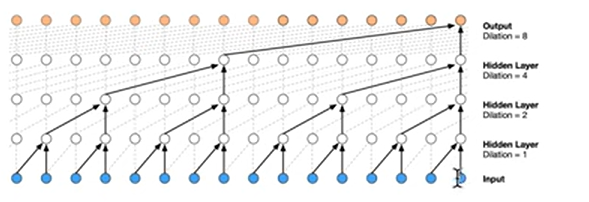


In [ ]:
model.layers[0].out.shape #output of embedding layer

In [ ]:
model.layers[1].out.shape #output of flatten layer

In [ ]:
model.layers[2].out.shape #output of Linear layer

In [ ]:
(torch.randn(4, 5, 6, 80) @ torch.randn(80, 200) + torch.randn(200)).shape
#multiplication happens on the last dimension

In [ ]:
(torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape
#currant state

In [ ]:
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape
# needed them to be in (4, 4, 20) # 4 vectors of 20

In [ ]:
c1 = torch.tensor(list(range(10))).view(1, -1) # even indexes
c1[1::2] # odd indexes
print(c1[:, 1::2], c1[:, ::2])
torch.cat([c1[:, 1::2], c1[:, ::2]], 0)
a = torch.tensor([[[1], [3], [5], [7], [9]]])
b = torch.tensor([[[0], [2], [4], [6], [8]]])
torch.cat([a, b], 2)


In [ ]:
e = torch.randn(4, 8 , 10) #goal want this to be (4, 4, 20) where consective 10-d vectors get concatenated 
print(e[:1, ::2, :])
print(e[:1, 1::2, :])
torch.cat([e[:1, ::2, :], e[:1, 1::2, :]], 2)
e.view(4, 4, 20)[:1,:,:]


In [ ]:
# (1 ,2) (3, 4), (5, 6) (7, 8)
# instead of feeding [n, 80] shape vectors into hidden layer in one go or early, we want move progressively like in binary tree mode 

In [311]:
#same optimization as the last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix]

    #forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) #loss function

    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    #update
    lr = 0.1 if i < 150000 else 0.01 #step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d} : {loss.item(): .4f}')
    lossi.append(loss.log10().item())

    break # would take out obviously to run full optimization



      0/ 200000 :  3.2942


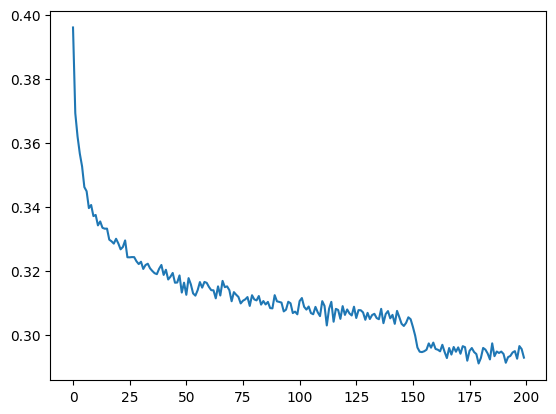

In [296]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [312]:
#put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [313]:
# evaluate the loss
@torch.no_grad()

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y) #loss function
    print(split, loss.item())


split_loss('train')
split_loss('val')
    



train 3.2791085243225098
val 3.279268503189087


In [314]:
# sample from the model

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

ez.
qizpl.
yq.
.
nogpvvi.
atskbxbnqfcgmwzxekdpmdbhjbikmmbmuxxotuypsywvsbn.
dburhcrehwjtitolzl.
asy.
fearjumydtwaohfwhgbudw.
xzzinl.
nffkgekgekxlnhrycgqfgbxupn.
wxbpienqhcbmq.
pecgqlikldasomwbfgemkgupwug.
tuakbvsajabdhzhzbphcwtn.
he.
yiuqsaudkfziuwwqysozfvwbffuzipixummtxbakwfpduchipdtfoppadkvp.
hxzuvbxdxrztfbztikmrjtkavqvwncpj.
tgxdwivoxbdpaxzxdnuepwvsuolhrhfexntzvodqdvhrghosnatbz.
cnihzwmmtuohnylqcunuexfdqkuzud.
zheeiwaho.


In [315]:
# why convolutions? brief preview or hint
for x, y in zip(Xtr[7:15], Ytr[7:15]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .


In [316]:
# experimental harness
# forward a single example
logits = model(Xtr[[7]])
logits.shape

torch.Size([1, 27])

In [317]:
# forward all of them
logits = torch.zeros(8, 27)
for i in range(8):
    logits[i] = model(Xtr[[7 + i]])

logits.shape

torch.Size([8, 27])

In [ ]:
# convolution is a for loop
# allows us to forward linear layers efficiently over space

# convolutional allows the model to slide efficiently over the input sequence, 
# rather making 8 independent call to model
# We slide the linear filter over the input sequqnce
# we calculate 1st layer, 2nd layer and so on. 

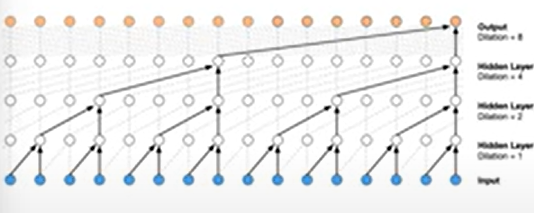
